# 05 · Tuning a policy with Optuna

A textbook policy is only as good as its hyperparameters. `src.tuning` wraps
[Optuna](https://optuna.org/) around the simulator to **search** a policy's
hyperparameters for the configuration that squeezes the most profit out of every
opening dollar — then re-checks the winners on a held-out seed set so the result
isn't a fluke.

How a study works:

1. Each **trial** proposes one set of hyperparameters.
2. That candidate policy is run across a **fixed set of seeded episodes** (Common
   Random Numbers), each spanning a randomly sampled node *capacity* and opening
   *balance* — so the score reflects the policy, not lucky draws.
3. The objective is **normalised return** = `net_profit / initial_cash`, averaged
   over seeds. Being dimensionless, it's comparable across two orders of magnitude
   of node size.
4. After the search, the **top-K** trials are re-evaluated on a *disjoint* holdout
   seed set and compared head-to-head against the published default policy.

This notebook runs a **tiny demo study** so it finishes in seconds and needs no API
key. The goal is to show how to *drive* a study and, above all, how to **inspect the
artifacts it leaves on disk**.

> Demo vs. real run. The shipped defaults (`TuningConfig`) are `n_trials=150`,
> `n_search_seeds=16`, `n_holdout_seeds=32`, `episode_length=365` — a sequential
> run of ~40–80 min. We shrink every one of those knobs below.

In [1]:
%matplotlib inline
import os
from pathlib import Path

# Hop up to the repo root so `import src...` and relative paths resolve
# no matter where the kernel started.
while not (Path.cwd() / "pyproject.toml").exists():
    os.chdir("..")

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
plt.rcParams["figure.dpi"] = 90
print("cwd:", Path.cwd())

cwd: /Users/mislavjordanic/Documents/projects/personal_projects/supply_chain_simulator


## 1 · A synthetic catalog — no LLM, no API key

The tuner samples each episode's active SKUs from a product universe. `src.tuning`
ships `make_synthetic_catalog(n)` for exactly this — a deterministic `n`-product
catalog with stable ids and sane pricing, so a study runs with zero external
dependencies.

In [2]:
from src.tuning import make_synthetic_catalog

catalog = make_synthetic_catalog(20)   # 20-SKU universe
print(f"catalog: {len(catalog)} products")

pd.DataFrame(
    [(w.product_id, w.name, w.category, w.base_price, w.unit_cost) for w in catalog[:5]],
    columns=["product_id", "name", "category", "base_price", "unit_cost"],
)

catalog: 20 products


,product_id,name,category,base_price,unit_cost
0,P0000,Product 0,General,10.0,4.0
1,P0001,Product 1,General,11.0,5.0
2,P0002,Product 2,General,12.0,6.0
3,P0003,Product 3,General,13.0,7.0
4,P0004,Product 4,General,14.0,8.0


## 2 · A tiny `TuningConfig`

`TuningConfig` is a frozen dataclass holding every knob a study reads — episode shape,
the capacity / balance randomisation distributions, simulator settings, and the study
parameters. We override the study knobs to *tiny* values so the demo finishes fast;
everything else keeps its default.

In [3]:
from src.tuning import TuningConfig

config = TuningConfig(
    n_trials=20,          # vs 150 default
    n_search_seeds=6,     # vs 16 default — CRN seeds per trial
    n_holdout_seeds=8,    # vs 32 default — disjoint confirmation seeds
    episode_length=90,    # vs 365 default — ticks per episode
    K_active=4,           # active SKUs per episode (sampled from the catalog)
    top_k_for_holdout=3,  # how many winners to re-check
    sampler_seed=7,       # reproducible sampling
)

# The capacity / balance domain randomisation each episode sees:
print("capacity_dist :", config.capacity_dist)
print("balance_dist  :", config.balance_dist)
print("episode_length:", config.episode_length, "ticks")
print("search seeds  :", config.n_search_seeds, "| holdout seeds:", config.n_holdout_seeds)

capacity_dist : LogUniform(low=100, high=10000)
balance_dist  : LogUniform(low=10000, high=1000000)
episode_length: 90 ticks
search seeds  : 6 | holdout seeds: 8


## 3 · Run the study

`run_study` is the entry point. Its signature:

```python
run_study(
    policy_space,            # f(trial) -> Policy  (a *_space factory)
    *,
    catalog,                 # list[Ware]
    tuning_config,           # TuningConfig
    study_name,              # str — used as the output sub-directory
    output_dir="runs/tuning",
    market_params=None,
    disruption_params=None,
) -> optuna.Study
```

We tune `OrderUpToPolicy` via the bundled `order_up_to_space` factory. It samples
five hyperparameters per trial: `cover_horizon_ticks`, `safety_lead_pct_of_lag`,
`stockout_safety_bonus_pct_of_lag`, `per_supplier_min_order_floor`, and a categorical
`routing_strategy`.

Artifacts land under `{output_dir}/{study_name}/`. We point that at a notebook-local
demo directory.

In [4]:
import time
from src.tuning import order_up_to_space, run_study

OUTPUT_DIR = "data/notebook_demos/05"
STUDY_NAME = "order_up_to_demo"
STUDY_DIR = Path(OUTPUT_DIR) / STUDY_NAME

t0 = time.time()
study = run_study(
    order_up_to_space,
    catalog=catalog,
    tuning_config=config,
    study_name=STUDY_NAME,
    output_dir=OUTPUT_DIR,
)
wall = time.time() - t0

print(f"study finished in {wall:.1f}s — {len(study.trials)} trials")
print("best normalised return:", round(study.best_value, 4))
print("artifacts written to:", STUDY_DIR)
print("  ", sorted(p.name for p in STUDY_DIR.iterdir()))

study finished in 3.1s — 20 trials
best normalised return: 0.4968
artifacts written to: data/notebook_demos/05/order_up_to_demo
   ['holdout.parquet', 'holdout_summary.json', 'per_seed.parquet', 'study.json', 'trials.parquet']


## 4 · Inspect the results

This is the main event. The study wrote three portable artifacts — two Parquet tables
and one JSON. They load with just `pandas` (+ `pyarrow`); no Optuna needed to read them.

### 4.1 · `trials.parquet` — one row per trial

Always check `.columns` before assuming shapes. The fixed KPI columns come first, then
one column per sampled hyperparameter.

In [5]:
trials = pd.read_parquet(STUDY_DIR / "trials.parquet")

print("columns:", list(trials.columns))
print("shape:", trials.shape)
trials.head()

columns: ['trial_id', 'state', 'datetime_start', 'datetime_complete', 'duration_s', 'mean_normalised_return', 'mean_net_profit', 'mean_service_level', 'mean_stockout_rate', 'mean_inventory_turnover', 'mean_revenue', 'mean_mean_price_pct_of_msrp', 'cover_horizon_ticks', 'safety_lead_pct_of_lag', 'stockout_safety_bonus_pct_of_lag', 'per_supplier_min_order_floor', 'routing_strategy']
shape: (20, 17)


,trial_id,state,datetime_start,datetime_complete,duration_s,mean_normalised_return,mean_net_profit,mean_service_level,mean_stockout_rate,mean_inventory_turnover,mean_revenue,mean_mean_price_pct_of_msrp,cover_horizon_ticks,safety_lead_pct_of_lag,stockout_safety_bonus_pct_of_lag,per_supplier_min_order_floor,routing_strategy
0,0,COMPLETE,2026-06-08 18:09:07.811604,2026-06-08 18:09:07.972165,0.160561,0.459858,32783.870000,1.0,0.003241,44.726791,70741.333333,1.0,3,2.339756,0.876818,7,cheapest_first
1,1,COMPLETE,2026-06-08 18:09:07.972195,2026-06-08 18:09:08.118939,0.146744,0.493531,35054.231667,1.0,0.051852,28.033014,65752.500000,1.0,16,0.216153,0.536878,5,fill_rate_weighted
2,2,COMPLETE,2026-06-08 18:09:08.118967,2026-06-08 18:09:08.269079,0.150112,0.496809,35678.415000,1.0,0.050926,28.299982,65785.833333,1.0,12,0.197809,0.576291,10,fill_rate_weighted
3,3,COMPLETE,2026-06-08 18:09:08.269108,2026-06-08 18:09:08.414658,0.145550,0.475530,34002.610000,1.0,0.042130,30.289554,66723.833333,1.0,28,0.074698,1.201098,10,fill_rate_weighted
4,4,COMPLETE,2026-06-08 18:09:08.414681,2026-06-08 18:09:08.561506,0.146825,0.466619,33386.750000,1.0,0.015278,38.360099,69292.166667,1.0,28,0.399508,1.046825,8,cheapest_first


### 4.2 · `per_seed.parquet` — one row per (trial, seed)

The long-format companion: every trial's score broken out by seed, with the per-episode
`capacity` and `initial_cash` that seed drew. This is what makes the score robust — and
lets you see *variance across seeds*, not just the mean.

In [6]:
per_seed = pd.read_parquet(STUDY_DIR / "per_seed.parquet")

print("columns:", list(per_seed.columns))
print("shape:", per_seed.shape, "=", per_seed["trial_id"].nunique(),
      "trials ×", per_seed["seed"].nunique(), "seeds")
per_seed.head()

columns: ['trial_id', 'seed', 'capacity', 'initial_cash', 'net_profit', 'normalised_return', 'service_level', 'stockout_rate', 'inventory_turnover', 'revenue', 'mean_price_pct_of_msrp']
shape: (120, 11) = 20 trials × 6 seeds


,trial_id,seed,capacity,initial_cash,net_profit,normalised_return,service_level,stockout_rate,inventory_turnover,revenue,mean_price_pct_of_msrp
0,0,12000000,8234.0,36608.350108,35725.07,0.975872,1.0,0.000000,0.699007,70213.0,1.0
1,0,12000001,131.0,25501.581763,26970.87,1.057616,1.0,0.019444,179.393010,69242.0,1.0
2,0,12000002,204.0,95020.193210,24680.93,0.259744,1.0,0.000000,48.063365,70649.0,1.0
3,0,12000003,3596.0,616138.327922,62583.50,0.101574,1.0,0.000000,3.322048,88583.0,1.0
4,0,12000004,1925.0,64893.798060,18779.51,0.289388,1.0,0.000000,11.197190,54719.0,1.0


### 4.3 · `study.json` — self-describing metadata

The study's provenance: the search space it explored, the best trial, the git SHA, and
the wall-clock window.

In [7]:
import json

study_meta = json.loads((STUDY_DIR / "study.json").read_text())

print("study_name        :", study_meta["study_name"])
print("policy_class_name :", study_meta["policy_class_name"])
print("n_trials          :", study_meta["n_trials"])
print("best_trial_id     :", study_meta["best_trial_id"])
print("best_value        :", round(study_meta["best_value"], 4))
print("\nsearch_space:")
for name, spec in study_meta["search_space"].items():
    print(f"  {name:34s} {spec}")

study_name        : order_up_to_demo
policy_class_name : OrderUpToPolicy
n_trials          : 20
best_trial_id     : 2
best_value        : 0.4968

search_space:
  cover_horizon_ticks                {'type': 'int', 'low': 1, 'high': 30}
  safety_lead_pct_of_lag             {'type': 'float', 'low': 0.0, 'high': 3.0}
  stockout_safety_bonus_pct_of_lag   {'type': 'float', 'low': 0.0, 'high': 2.0}
  per_supplier_min_order_floor       {'type': 'int', 'low': 0, 'high': 10}
  routing_strategy                   {'type': 'categorical', 'choices': ['cheapest_first', 'fill_rate_weighted']}


### 4.4 · The optimisation trajectory

Trial index vs. objective. We also track the **running best** — the cumulative max — to
see how quickly the search closed in on its winner.

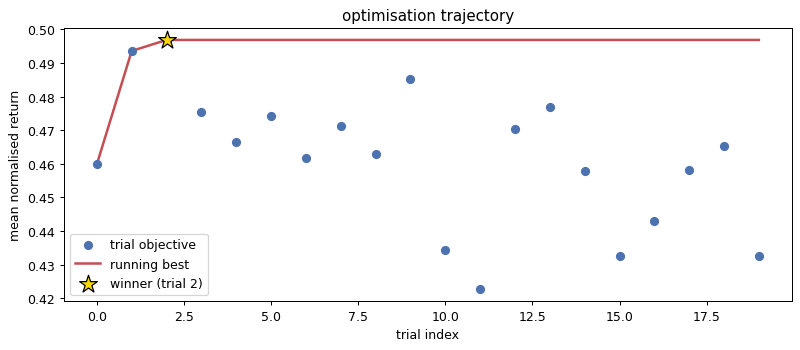

In [8]:
completed = trials[trials["state"] == "COMPLETE"].sort_values("trial_id").copy()
completed["running_best"] = completed["mean_normalised_return"].cummax()

best_id = study_meta["best_trial_id"]
best_val = study_meta["best_value"]

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(completed["trial_id"], completed["mean_normalised_return"],
           s=40, color="#4C72B0", label="trial objective", zorder=3)
ax.plot(completed["trial_id"], completed["running_best"],
        color="#C44E52", lw=2, label="running best", zorder=2)
ax.scatter([best_id], [best_val], s=220, marker="*", color="gold",
           edgecolor="black", zorder=4, label=f"winner (trial {best_id})")
ax.set_xlabel("trial index")
ax.set_ylabel("mean normalised return")
ax.set_title("optimisation trajectory")
ax.legend()
plt.tight_layout()
plt.show()

### 4.5 · Parameter sensitivity

Each tuned hyperparameter vs. the objective. Flat clouds mean the policy is insensitive
to that knob; a clear slope or clustering means it matters. The categorical
`routing_strategy` gets a box-style strip instead of a scatter.

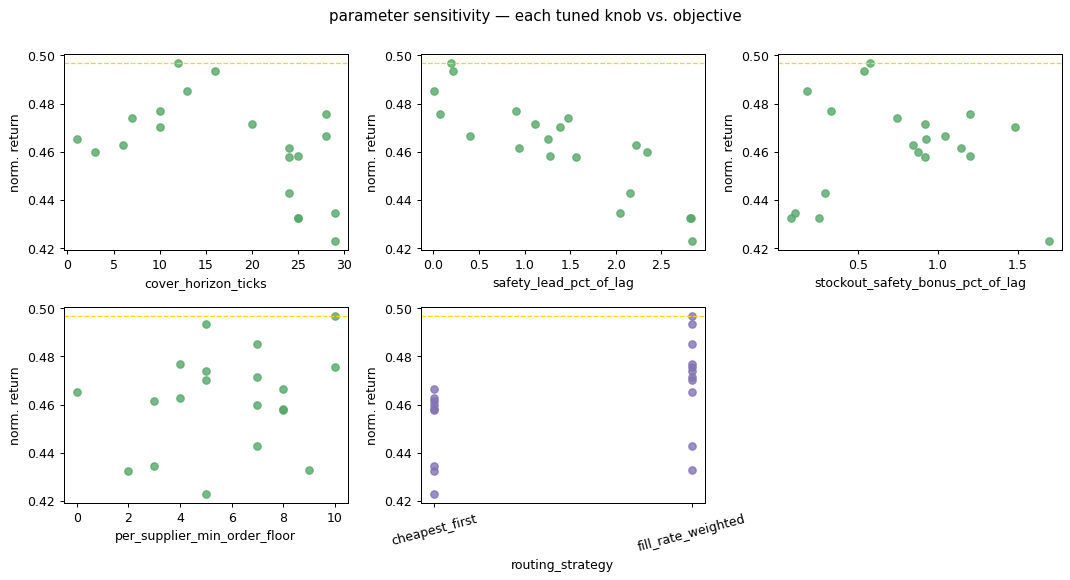

In [9]:
param_cols = list(study_meta["search_space"].keys())
numeric_params = [p for p in param_cols if study_meta["search_space"][p]["type"] != "categorical"]
cat_params = [p for p in param_cols if study_meta["search_space"][p]["type"] == "categorical"]

n_panels = len(numeric_params) + len(cat_params)
ncols = 3
nrows = (n_panels + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.2 * nrows))
axes = axes.ravel()

y = completed["mean_normalised_return"]
for ax, p in zip(axes, numeric_params):
    ax.scatter(completed[p], y, s=35, color="#55A868", alpha=0.8)
    ax.axhline(best_val, color="gold", ls="--", lw=1)
    ax.set_xlabel(p)
    ax.set_ylabel("norm. return")

for ax, p in zip(axes[len(numeric_params):], cat_params):
    cats = sorted(completed[p].dropna().unique())
    for i, c in enumerate(cats):
        vals = completed.loc[completed[p] == c, "mean_normalised_return"]
        ax.scatter([i] * len(vals), vals, s=35, color="#8172B3", alpha=0.8)
    ax.set_xticks(range(len(cats)))
    ax.set_xticklabels(cats, rotation=15)
    ax.axhline(best_val, color="gold", ls="--", lw=1)
    ax.set_xlabel(p)
    ax.set_ylabel("norm. return")

for ax in axes[n_panels:]:
    ax.axis("off")

fig.suptitle("parameter sensitivity — each tuned knob vs. objective", y=1.0)
plt.tight_layout()
plt.show()

### 4.6 · The winning trial's parameters

The hyperparameters Optuna settled on, alongside their KPIs.

In [10]:
best_row = trials.loc[trials["trial_id"] == best_id].iloc[0]

print(f"=== winner: trial {best_id} (mean normalised return = {best_val:.4f}) ===\n")

print("tuned hyperparameters:")
best_params = pd.Series({p: best_row[p] for p in param_cols}, name="value")
display(best_params.to_frame())

print("\nKPIs:")
kpi_cols = [c for c in trials.columns if c.startswith("mean_")]
display(best_row[kpi_cols].to_frame("value"))

=== winner: trial 2 (mean normalised return = 0.4968) ===

tuned hyperparameters:


,value
cover_horizon_ticks,12
safety_lead_pct_of_lag,0.197809
stockout_safety_bonus_pct_of_lag,0.576291
per_supplier_min_order_floor,10
routing_strategy,fill_rate_weighted



KPIs:


,value
mean_normalised_return,0.496809
mean_net_profit,35678.415
mean_service_level,1.0
mean_stockout_rate,0.050926
mean_inventory_turnover,28.299982
mean_revenue,65785.833333
mean_mean_price_pct_of_msrp,1.0


## 5 · Confirm the winners on held-out seeds

`confirm_top_k` re-evaluates the top-K search trials **plus the published default**
(`OrderUpToPolicy()` with no kwargs) on a *disjoint* holdout seed set, then writes
`holdout.parquet` and `holdout_summary.json` with bootstrap confidence intervals and
the headline paired uplift (tuned − default).

```python
confirm_top_k(
    study,
    policy_space,
    *,
    catalog,
    tuning_config,
    study_dir,               # where holdout.* land — pass the study sub-dir
    market_params=None,
    disruption_params=None,
) -> dict   # the holdout summary
```

It re-runs the policies, but on our tiny config that's still well under a second.

In [11]:
from src.tuning import confirm_top_k

t0 = time.time()
summary = confirm_top_k(
    study,
    order_up_to_space,
    catalog=catalog,
    tuning_config=config,
    study_dir=str(STUDY_DIR),
)
print(f"confirm_top_k finished in {time.time() - t0:.2f}s\n")

for k, v in summary.items():
    print(f"  {k:28s} {round(v, 2) if isinstance(v, float) else v}")

confirm_top_k finished in 0.83s

  tuned_best_label             tuned_rank_1
  tuned_best_mean_net_profit   29302.19
  tuned_best_ci_low            23896.35
  tuned_best_ci_high           33765.81
  default_mean_net_profit      29738.2
  default_ci_low               24710.95
  default_ci_high              34368.08
  headline_uplift              -436.01
  headline_uplift_ci_low       -1149.4
  headline_uplift_ci_high      270.86
  n_holdout_seeds              8


### The held-out comparison

`holdout.parquet` carries every (label, seed) row. The headline compares `tuned_rank_1`
— the search winner, chosen *before* seeing the holdout to avoid winner's-curse bias —
against the published `default`.

In [12]:
holdout = pd.read_parquet(STUDY_DIR / "holdout.parquet")
print("labels:", sorted(holdout["label"].unique()))

per_label = (
    holdout.groupby("label")["net_profit"]
    .agg(["mean", "std", "count"])
    .sort_values("mean", ascending=False)
)
display(per_label)

tuned_mean = summary["tuned_best_mean_net_profit"]
default_mean = summary["default_mean_net_profit"]
uplift = summary["headline_uplift"]
print(f"\ntuned_rank_1 mean net profit : {tuned_mean:,.0f}")
print(f"default      mean net profit : {default_mean:,.0f}")
print(f"headline paired uplift       : {uplift:,.0f} "
      f"(95% CI [{summary['headline_uplift_ci_low']:,.0f}, "
      f"{summary['headline_uplift_ci_high']:,.0f}])")

labels: ['default', 'tuned_rank_1', 'tuned_rank_2', 'tuned_rank_3']


,mean,std,count
label,,,
default,29738.20375,7848.138389,8
tuned_rank_3,29359.46000,7757.302229,8
tuned_rank_1,29302.19125,7998.202505,8
tuned_rank_2,28875.75250,7796.265512,8



tuned_rank_1 mean net profit : 29,302
default      mean net profit : 29,738
headline paired uplift       : -436 (95% CI [-1,149, 271])


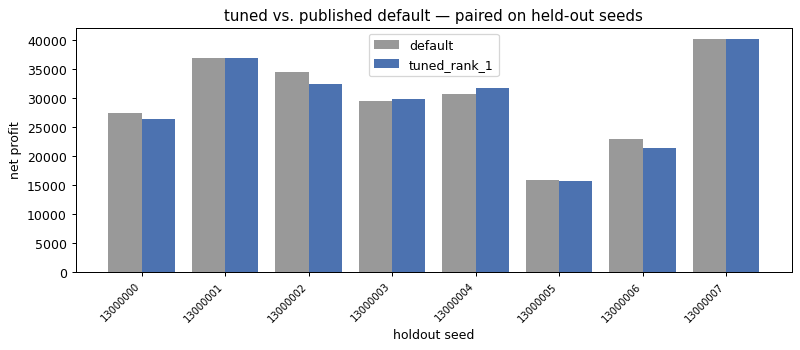

,default,tuned_rank_1,uplift
seed,,,
13000000,27435.14,26304.18,-1130.96
13000001,36969.98,36969.98,0.00
13000002,34557.09,32329.93,-2227.16
13000003,29536.61,29768.99,232.38
13000004,30602.48,31775.45,1172.97
13000005,15832.38,15721.84,-110.54
13000006,22824.00,21399.21,-1424.79
13000007,40147.95,40147.95,0.00


In [13]:
# Paired per-seed view: tuned vs default on the *same* holdout seeds (CRN).
tuned = holdout[holdout["label"] == "tuned_rank_1"].set_index("seed")["net_profit"]
default = holdout[holdout["label"] == "default"].set_index("seed")["net_profit"]
paired = pd.DataFrame({"default": default, "tuned_rank_1": tuned})
paired["uplift"] = paired["tuned_rank_1"] - paired["default"]

fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(paired))
ax.bar([i - 0.2 for i in x], paired["default"], width=0.4, label="default", color="#999999")
ax.bar([i + 0.2 for i in x], paired["tuned_rank_1"], width=0.4, label="tuned_rank_1", color="#4C72B0")
ax.set_xticks(list(x))
ax.set_xticklabels(paired.index, rotation=45, ha="right", fontsize=8)
ax.set_xlabel("holdout seed")
ax.set_ylabel("net profit")
ax.set_title("tuned vs. published default — paired on held-out seeds")
ax.legend()
plt.tight_layout()
plt.show()

display(paired)

## Where to next

- This was a *tiny* demo. For a real result, drop the `TuningConfig` overrides (or just
  run `TuningConfig()`) and budget ~40–80 min — or use the CLI:
  `uv run python -m src.tuning.study --policy order_up_to --trials 150 --study-name my_run`.
- Swap `order_up_to_space` for `reorder_point_space`, `periodic_order_up_to_space`, or
  `periodic_reorder_space` to tune the other three textbook variants — same artifacts,
  extra `Q` / `review_interval` columns.
- Point `--setup-dir` (or `market_params=`) at a real setup to tune against a specific
  catalog and market instead of the synthetic one.
- Once you have a real study on disk, **notebook 05a** loads it back and analyzes it in
  depth (parameter importance, leaderboard, seed-robustness, holdout confirmation).

| notebook | topic |
|---|---|
| **04** | compare the four textbook policies under Common Random Numbers |
| **05** | tune a policy with Optuna *(this notebook)* |
| **05a** | analyze a completed tuning study from disk |
| **06** | train a PPO agent and evaluate it against the textbook baseline |